# LSTM模型进行发电功率预测

导入包

In [ ]:
import numpy as np
import os
import tensorflow as tf
import random
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import GRU
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn import metrics
from numpy import array
from numpy import hstack
from math import sqrt

from sklearn.metrics import mean_squared_error


2026-01-06 19:25:51.531752: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-06 19:25:51.662024: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-06 19:25:51.694654: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-06 19:25:52.238796: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

In [3]:
# physical_devices = tf.config.experimental.list_physical_devices('GPU')
# assert len(physical_devices) > 0, "Not enough GPU hardware devices available"
# tf.config.experimental.set_memory_growth(physical_devices[0], True)


# import tensorflow as tf 
# tf.compat.v1.disable_eager_execution()
# os.environ['CUDA_VISIBLE_DEVICES']="0" # 指定哪块GPU训练
# config=tf.compat.v1.ConfigProto() 
# # 设置最大占有GPU不超过显存的80%（可选）
# config.gpu_options.per_process_gpu_memory_fraction=0.7
# config.gpu_options.allow_growth = True  # 设置动态分配GPU内存
# sess=tf.compat.v1.Session(config=config)

# print(tf.config.experimental.list_physical_devices('GPU'))
# print(tf.__version__)
# physical_devices = tf.config.experimental.list_physical_devices('GPU')
# assert len(physical_devices) > 0, "Not enough GPU hardware devices available"
# tf.config.experimental.set_memory_growth(physical_devices[0], True)

# print(tf.test.is_gpu_available())




In [ ]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
	X, y = list(), list()
	for i in range(len(sequences)):
		# find the end of this pattern
		end_ix = i + n_steps_in
		out_end_ix = end_ix + n_steps_out-1
		# check if we are beyond the dataset
		if out_end_ix > len(sequences):
			break
		# gather input and output parts of the pattern
# 		seq_x, seq_y = sequences[i:end_ix, :-1], sequences[(i+(n_steps_in - n_steps_out)):end_ix, -1]
		seq_x, seq_y = sequences[i:end_ix, :-1], sequences[i:end_ix, -1]
		X.append(seq_x)
		y.append(seq_y)
	return array(X), array(y)



In [6]:
def seed_tensorflow(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
seed_tensorflow(1)

添加时间变量函数，将时间添加到输入参数当中

In [7]:
def add_time_variables(df: pd.DataFrame) -> pd.DataFrame:
    """
    添加时间变量
    :param df:
    :return:
    """
    df['minute_of_day'] = df.index.hour * 60 + df.index.minute
    df['hour_of_day'] = df.index.hour
    df['month'] = df.index.month
    df['day_of_month'] = df.index.day
#     df['doy'] = df.index.dayofyear
    return df

读取clean后的数据，并将空值转换为0

In [ ]:
# df=pd.read_csv(r"./add_time_era5gfs_72h.csv",parse_dates=["time"],index_col=[0])
df=pd.read_csv(r"./era5gfs_72h.csv")
# df = df.iloc[:,-3:]
# df.drop('Unnamed: 0',axis = 1,inplace = True)

# 按年月日划分训练集和测试集
df['time']= pd.to_datetime(df['time']) 
df['Year'] = df['time'].dt.year 
df['Month'] = df['time'].dt.month
df['Day'] = df['time'].dt.day

df.set_index(keys = 'time',inplace = True)

where_are_nan = np.isnan(df)
where_are_inf = np.isinf(df)
df[where_are_nan] = 0
df[where_are_inf] = 0

# df = add_time_variables(df)
df = df.fillna(value = 0)
df.shape

(8664, 9)

In [801]:
df.head()

,ssr-1,pev-1,ishf-1,Potential_Evaporation_Rate_surface,lanneng-1,lanneng,Year,Month,Day
time,,,,,,,,,
2021-01-05 00:00:00,0.0,0.000001,-3.369225,8.922050,0.0,0.0,2021,1,5
2021-01-05 01:00:00,0.0,0.000001,-4.332596,8.631925,0.0,0.0,2021,1,5
2021-01-05 02:00:00,0.0,0.000001,-4.505280,8.341800,0.0,0.0,2021,1,5
2021-01-05 03:00:00,0.0,0.000001,-4.350777,9.092356,0.0,0.0,2021,1,5
2021-01-05 04:00:00,0.0,0.000001,-4.459839,9.842911,0.0,0.0,2021,1,5


In [ ]:
from sklearn.model_selection import train_test_split

# df_for_training = df_for_testing = train_test_split(df,train_size = 0.7 , shuffle =False)
# df_for_training = df_for_training.sort_index()
# df_for_testing = df_for_testing.sort_index()

# df_for_training = df_for_training.drop(labels = ['Year','Month','Day'], axis = 1)

# df_for_testing = df_for_testing.drop(labels = ['Year','Month','Day'] ,axis = 1)
# df_for_training = df.sample(frac = 0.7)
# print(df_for_training.shape)
# print(df_for_training)
# df_for_testing = df.drop(labels = df_for_training.index)

df_for_training = df.loc[df['Day']<=21]
df_for_testing  = df.loc[df['Day']>21]

df_for_training = df_for_training.drop(labels = ['Year','Month','Day'], axis = 1)
df_for_testing = df_for_testing.drop(labels = ['Year','Month','Day'] ,axis = 1)

使用后3000条数据进行train和test，其中后3000条的前2400条进行train，后600条进行测test

In [803]:
df_for_testing

,ssr-1,pev-1,ishf-1,Potential_Evaporation_Rate_surface,lanneng-1,lanneng
time,,,,,,
2021-01-22 00:00:00,0.0,2.040000e-06,3.001785,-1.537906,0.0,0.0
2021-01-22 01:00:00,0.0,2.210000e-06,2.720047,5.168829,0.0,0.0
2021-01-22 02:00:00,0.0,2.320000e-06,2.665512,11.875564,0.0,0.0
2021-01-22 03:00:00,0.0,1.970000e-06,2.501923,13.958774,0.0,0.0
2021-01-22 04:00:00,0.0,2.160000e-06,2.483749,16.041985,0.0,0.0
...,...,...,...,...,...,...
2021-12-31 19:00:00,0.0,-1.280000e-06,-5.468658,35.319997,0.0,0.0
2021-12-31 20:00:00,0.0,-9.750000e-07,-5.195999,18.802275,0.0,0.0
2021-12-31 21:00:00,0.0,-1.180000e-06,-4.559807,19.996650,0.0,0.0


In [ ]:


print(df_for_testing['power'].head(10))



time
2021-01-22 00:00:00    0.0000
2021-01-22 01:00:00    0.0000
2021-01-22 02:00:00    0.0000
2021-01-22 03:00:00    0.0000
2021-01-22 04:00:00    0.0000
2021-01-22 05:00:00    0.0000
2021-01-22 06:00:00    0.0000
2021-01-22 07:00:00    0.0000
2021-01-22 08:00:00    1.6948
2021-01-22 09:00:00    3.5743
Name: lanneng, dtype: float64


In [805]:
scaler = MinMaxScaler(feature_range=(0,1))
df_for_training_scaled = scaler.fit_transform(df_for_training)

In [806]:
df_for_testing_scaled=scaler.transform(df_for_testing)

In [807]:
df_for_training_scaled.shape

(5952, 6)

In [808]:
df_for_testing_scaled.shape

(2712, 6)

In [809]:
def createXY(dataset,n_past):
    dataX = []
    dataY = []
    for i in range(n_past, len(dataset)):
            dataX.append(dataset[i - n_past:i, 0:dataset.shape[1]])
            dataY.append(dataset[i,53])
    return np.array(dataX),np.array(dataY)        


确定时间步长timestep，即用几行数据去预测下一个数据（dense=1所以是预测一个）

In [811]:
# ------关键！！选择输入输出，即时间步长和预测步长！！！------

# choose a number of time steps
n_steps_in, n_steps_out = 72, 72
# covert into input/output
trainX,trainY = split_sequences(df_for_training_scaled, n_steps_in, n_steps_out)
testX,testY = split_sequences(df_for_testing_scaled, n_steps_in, n_steps_out)
# the dataset knows the number of features, e.g. 2
n_features = trainX.shape[2]


In [812]:
print(trainX.shape)

(5810, 72, 5)


In [813]:
print(trainX)

[[[0.         0.97075838 0.7727156  0.02640491 0.        ]
  [0.         0.97094312 0.77024157 0.02615291 0.        ]
  [0.         0.97094312 0.76979811 0.02590092 0.        ]
  ...
  [0.         0.96562526 0.78709299 0.17314863 0.        ]
  [0.         0.96578361 0.78842339 0.17066206 0.        ]
  [0.         0.96569124 0.79901973 0.16817549 0.        ]]

 [[0.         0.97094312 0.77024157 0.02615291 0.        ]
  [0.         0.97094312 0.76979811 0.02590092 0.        ]
  [0.         0.97083756 0.77019488 0.02655283 0.        ]
  ...
  [0.         0.96578361 0.78842339 0.17066206 0.        ]
  [0.         0.96569124 0.79901973 0.16817549 0.        ]
  [0.         0.96565166 0.80606841 0.16532517 0.        ]]

 [[0.         0.97094312 0.76979811 0.02590092 0.        ]
  [0.         0.97083756 0.77019488 0.02655283 0.        ]
  [0.         0.97062643 0.7699148  0.02720474 0.        ]
  ...
  [0.         0.96569124 0.79901973 0.16817549 0.        ]
  [0.         0.96565166 0.8060684

In [815]:
print(trainY.shape)

(5810, 72)


In [816]:
print(trainY[0:10,:])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.01367186 0.0319871  0.05669894 0.08638236
  0.0527871  0.03439984 0.04792561 0.04269783 0.0012429  0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.06634991 0.07720673 0.09493653 0.09522977
  0.1875344  0.14278909 0.10323554 0.09851912 0.04240562 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.05337254 0.17422779 0.09870226 0.10681813
  0.21882701 0.1859993  0.17477619 0.16417453 0.06145137 0.
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.01367186 0.0319871  0.05669894 0.08638236 0.0527871
  0.03439984 0.04792561 0.04269783 0.0012429  0.         0.
  0.         0.         0.         0.         0.         0.


In [817]:
print(testY.shape)
testY

(2570, 72)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [818]:
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import GridSearchCV

构造模型，input_size的第一个参数是timestep，与前面对应一致

In [ ]:
# 初始模型
grid_model = Sequential()
# grid_model.add(tf.keras.layers.Dense(32, input_shape=(n_steps_in, n_features)))

# grid_model.add(tf.keras.layers.Conv1D(96, 1, activation='relu'))
# grid_model.add(LSTM(144,return_sequences=True,input_shape=(n_steps_in, n_features)))
# grid_model.add(Dropout(0.1))
# grid_model.add(LSTM(144))
# grid_model.add(Dropout(0.1))


grid_model.add(GRU(144,recurrent_activation='sigmoid',return_sequences=True,reset_after = True, input_shape=(n_steps_in, n_features)))
grid_model.add(Dropout(0.1))
grid_model.add(GRU(144, recurrent_activation='sigmoid',return_sequences=False))
grid_model.add(Dropout(0.1))

grid_model.add(tf.keras.layers.Dense(n_steps_out, activation='sigmoid'))

optimizer=tf.keras.optimizers.Adam()
grid_model.compile(optimizer=optimizer,
              loss=tf.keras.losses.MeanSquaredError(),
                  metrics = ['accuracy'])

checkpoint_save_path = "./checkpoint/LSTM_stock.ckpt" #模型保存位置

# if os.path.exists(checkpoint_save_path + '.index'):
#         print('-------------load the model-----------------')
#         grid_model.load_weights(checkpoint_save_path)

lr_reduce = keras.callbacks.ReduceLROnPlateau('val_loss',     
                                                  patience=4,
                                                  factor=0.7,
                                                  min_lr=0.00001)

# best_model = keras.callbacks.ModelCheckpoint(filepath=checkpoint_save_path,#保存模型
#                                                  monitor='val_loss',
#                                                  verbose=0,
#                                                  save_best_only=True,
#                                                  save_weights_only=True,
#                                                  mode='min',
#                                                  )

early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta = 0.00003 , patience=100,mode = 'max' )
 
# grid_model = KerasRegressor(build_fn=build_model,verbose=1)
# parameters = {'batch_size' : [64],
#               'epochs' : [2],
#               'optimizer' : ['adam','Adadelta'],
#              }

# grid_search  = GridSearchCV(estimator = grid_model,
#                             param_grid = parameters,
#                             cv = 2)

history = grid_model.fit(trainX,trainY,validation_data=(testX,testY),epochs = 800,batch_size = 72,
                         callbacks=[early_stop,lr_reduce],
                         verbose = 1,shuffle = False)

Epoch 1/800
81/81 [==============================] - 6s 33ms/step - loss: 0.0770 - accuracy: 0.0150 - val_loss: 0.0677 - val_accuracy: 0.0128 - lr: 0.0010
Epoch 2/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0520 - accuracy: 0.0325 - val_loss: 0.0339 - val_accuracy: 0.0689 - lr: 0.0010
Epoch 3/800
81/81 [==============================] - 2s 26ms/step - loss: 0.0313 - accuracy: 0.0797 - val_loss: 0.0273 - val_accuracy: 0.0899 - lr: 0.0010
Epoch 4/800
81/81 [==============================] - 2s 26ms/step - loss: 0.0276 - accuracy: 0.0979 - val_loss: 0.0260 - val_accuracy: 0.0911 - lr: 0.0010
Epoch 5/800
81/81 [==============================] - 2s 26ms/step - loss: 0.0258 - accuracy: 0.0952 - val_loss: 0.0257 - val_accuracy: 0.0981 - lr: 0.0010
Epoch 6/800
81/81 [==============================] - 2s 26ms/step - loss: 0.0235 - accuracy: 0.1040 - val_loss: 0.0320 - val_accuracy: 0.0673 - lr: 0.0010
Epoch 7/800
81/81 [==============================] - 2s 26ms/step - lo

81/81 [==============================] - 2s 25ms/step - loss: 0.0133 - accuracy: 0.2146 - val_loss: 0.0144 - val_accuracy: 0.2214 - lr: 1.6807e-04
Epoch 53/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0135 - accuracy: 0.2193 - val_loss: 0.0144 - val_accuracy: 0.2272 - lr: 1.6807e-04
Epoch 54/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0134 - accuracy: 0.2091 - val_loss: 0.0144 - val_accuracy: 0.2198 - lr: 1.6807e-04
Epoch 55/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0134 - accuracy: 0.2096 - val_loss: 0.0144 - val_accuracy: 0.2249 - lr: 1.6807e-04
Epoch 56/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0133 - accuracy: 0.2102 - val_loss: 0.0142 - val_accuracy: 0.2210 - lr: 1.1765e-04
Epoch 57/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0132 - accuracy: 0.2182 - val_loss: 0.0142 - val_accuracy: 0.2195 - lr: 1.1765e-04
Epoch 58/800
81/81 [==============================] -

81/81 [==============================] - 2s 25ms/step - loss: 0.0121 - accuracy: 0.2258 - val_loss: 0.0136 - val_accuracy: 0.2502 - lr: 1.0000e-05
Epoch 104/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0121 - accuracy: 0.2248 - val_loss: 0.0136 - val_accuracy: 0.2506 - lr: 1.0000e-05
Epoch 105/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0121 - accuracy: 0.2217 - val_loss: 0.0136 - val_accuracy: 0.2514 - lr: 1.0000e-05
Epoch 106/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0120 - accuracy: 0.2289 - val_loss: 0.0136 - val_accuracy: 0.2518 - lr: 1.0000e-05
Epoch 107/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0120 - accuracy: 0.2184 - val_loss: 0.0136 - val_accuracy: 0.2498 - lr: 1.0000e-05
Epoch 108/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0121 - accuracy: 0.2212 - val_loss: 0.0136 - val_accuracy: 0.2498 - lr: 1.0000e-05
Epoch 109/800
81/81 [===========================

Epoch 154/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0119 - accuracy: 0.2150 - val_loss: 0.0136 - val_accuracy: 0.2537 - lr: 1.0000e-05
Epoch 155/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0120 - accuracy: 0.2207 - val_loss: 0.0136 - val_accuracy: 0.2541 - lr: 1.0000e-05
Epoch 156/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0119 - accuracy: 0.2184 - val_loss: 0.0136 - val_accuracy: 0.2537 - lr: 1.0000e-05
Epoch 157/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0119 - accuracy: 0.2277 - val_loss: 0.0136 - val_accuracy: 0.2525 - lr: 1.0000e-05
Epoch 158/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0120 - accuracy: 0.2217 - val_loss: 0.0136 - val_accuracy: 0.2529 - lr: 1.0000e-05
Epoch 159/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0119 - accuracy: 0.2176 - val_loss: 0.0136 - val_accuracy: 0.2529 - lr: 1.0000e-05
Epoch 160/800
81/81 [=============

Epoch 205/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0118 - accuracy: 0.2146 - val_loss: 0.0136 - val_accuracy: 0.2518 - lr: 1.0000e-05
Epoch 206/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0118 - accuracy: 0.2172 - val_loss: 0.0136 - val_accuracy: 0.2518 - lr: 1.0000e-05
Epoch 207/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0118 - accuracy: 0.2227 - val_loss: 0.0136 - val_accuracy: 0.2510 - lr: 1.0000e-05
Epoch 208/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0118 - accuracy: 0.2256 - val_loss: 0.0136 - val_accuracy: 0.2525 - lr: 1.0000e-05
Epoch 209/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0118 - accuracy: 0.2181 - val_loss: 0.0136 - val_accuracy: 0.2518 - lr: 1.0000e-05
Epoch 210/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0118 - accuracy: 0.2196 - val_loss: 0.0135 - val_accuracy: 0.2521 - lr: 1.0000e-05
Epoch 211/800
81/81 [=============

Epoch 256/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0116 - accuracy: 0.2275 - val_loss: 0.0135 - val_accuracy: 0.2514 - lr: 1.0000e-05
Epoch 257/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0116 - accuracy: 0.2239 - val_loss: 0.0135 - val_accuracy: 0.2525 - lr: 1.0000e-05
Epoch 258/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0116 - accuracy: 0.2244 - val_loss: 0.0135 - val_accuracy: 0.2506 - lr: 1.0000e-05
Epoch 259/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0116 - accuracy: 0.2332 - val_loss: 0.0135 - val_accuracy: 0.2518 - lr: 1.0000e-05
Epoch 260/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0116 - accuracy: 0.2349 - val_loss: 0.0135 - val_accuracy: 0.2514 - lr: 1.0000e-05
Epoch 261/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0116 - accuracy: 0.2255 - val_loss: 0.0135 - val_accuracy: 0.2514 - lr: 1.0000e-05
Epoch 262/800
81/81 [=============

Epoch 307/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0115 - accuracy: 0.2334 - val_loss: 0.0135 - val_accuracy: 0.2545 - lr: 1.0000e-05
Epoch 308/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0115 - accuracy: 0.2179 - val_loss: 0.0135 - val_accuracy: 0.2545 - lr: 1.0000e-05
Epoch 309/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0115 - accuracy: 0.2344 - val_loss: 0.0135 - val_accuracy: 0.2545 - lr: 1.0000e-05
Epoch 310/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0114 - accuracy: 0.2305 - val_loss: 0.0135 - val_accuracy: 0.2541 - lr: 1.0000e-05
Epoch 311/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0115 - accuracy: 0.2330 - val_loss: 0.0135 - val_accuracy: 0.2556 - lr: 1.0000e-05
Epoch 312/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0115 - accuracy: 0.2312 - val_loss: 0.0135 - val_accuracy: 0.2541 - lr: 1.0000e-05
Epoch 313/800
81/81 [=============

Epoch 358/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0114 - accuracy: 0.2251 - val_loss: 0.0135 - val_accuracy: 0.2568 - lr: 1.0000e-05
Epoch 359/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0113 - accuracy: 0.2258 - val_loss: 0.0135 - val_accuracy: 0.2556 - lr: 1.0000e-05
Epoch 360/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0113 - accuracy: 0.2332 - val_loss: 0.0135 - val_accuracy: 0.2560 - lr: 1.0000e-05
Epoch 361/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0114 - accuracy: 0.2305 - val_loss: 0.0135 - val_accuracy: 0.2564 - lr: 1.0000e-05
Epoch 362/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0114 - accuracy: 0.2329 - val_loss: 0.0135 - val_accuracy: 0.2568 - lr: 1.0000e-05
Epoch 363/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0114 - accuracy: 0.2351 - val_loss: 0.0135 - val_accuracy: 0.2568 - lr: 1.0000e-05
Epoch 364/800
81/81 [=============

Epoch 409/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0113 - accuracy: 0.2232 - val_loss: 0.0135 - val_accuracy: 0.2595 - lr: 1.0000e-05
Epoch 410/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0112 - accuracy: 0.2306 - val_loss: 0.0135 - val_accuracy: 0.2591 - lr: 1.0000e-05
Epoch 411/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0112 - accuracy: 0.2191 - val_loss: 0.0135 - val_accuracy: 0.2588 - lr: 1.0000e-05
Epoch 412/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0112 - accuracy: 0.2291 - val_loss: 0.0135 - val_accuracy: 0.2568 - lr: 1.0000e-05
Epoch 413/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0112 - accuracy: 0.2260 - val_loss: 0.0135 - val_accuracy: 0.2580 - lr: 1.0000e-05
Epoch 414/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0112 - accuracy: 0.2353 - val_loss: 0.0135 - val_accuracy: 0.2584 - lr: 1.0000e-05
Epoch 415/800
81/81 [=============

Epoch 460/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0111 - accuracy: 0.2239 - val_loss: 0.0135 - val_accuracy: 0.2553 - lr: 1.0000e-05
Epoch 461/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0111 - accuracy: 0.2286 - val_loss: 0.0135 - val_accuracy: 0.2556 - lr: 1.0000e-05
Epoch 462/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0112 - accuracy: 0.2360 - val_loss: 0.0135 - val_accuracy: 0.2560 - lr: 1.0000e-05
Epoch 463/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0111 - accuracy: 0.2262 - val_loss: 0.0135 - val_accuracy: 0.2545 - lr: 1.0000e-05
Epoch 464/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0110 - accuracy: 0.2270 - val_loss: 0.0135 - val_accuracy: 0.2556 - lr: 1.0000e-05
Epoch 465/800
81/81 [==============================] - 2s 25ms/step - loss: 0.0111 - accuracy: 0.2244 - val_loss: 0.0135 - val_accuracy: 0.2560 - lr: 1.0000e-05
Epoch 466/800
81/81 [=============

绘制loss和accuracy曲线

{'verbose': 1, 'epochs': 800, 'steps': 81}


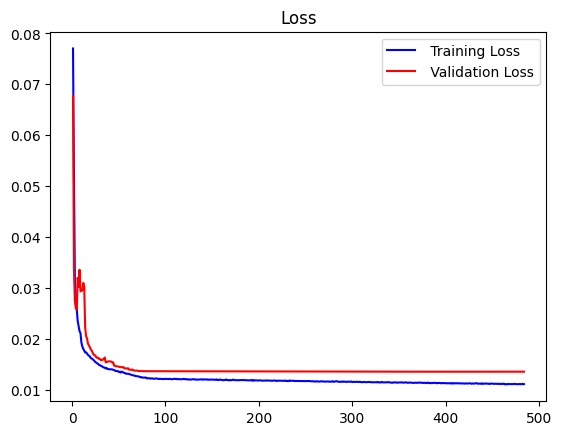

In [ ]:
print(history.params)
acc = history.history['accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
 
plt.title('Loss')
# plt.plot(epochs, acc, 'red', label=' Training acc')
plt.plot(epochs, loss, 'blue', label=' Training Loss')
plt.plot(epochs, val_loss, 'red', label=' Validation Loss')


plt.legend()
plt.savefig('./PredictModel/Fig_loss/GRU/ningbo_r08.jpg',dpi = 300)
plt.show()

计算训练时间

In [822]:
# import time
# t1 = time.perf_counter()
# grid_search = grid_search.fit(trainX,trainY)
# t2 = time.perf_counter()
# total_time = (t2-t1)*1000

In [823]:
# print(total_time)

In [ ]:
my_model = history

In [825]:
prediction=grid_model.predict(testX)
#print("prediction\n", prediction)
print("\nPrediction Shape-",prediction.shape)
print(prediction)
df = pd.DataFrame(prediction)
a=[]
for i in range(0,len(df),1):##每隔86行取数据
    a.append(i)
file = df.iloc[a].to_numpy()
prediction = file.flatten()
prediction
print(prediction.shape)

81/81 [==============================] - 1s 7ms/step

Prediction Shape- (2570, 72)
[[0.00234629 0.00229294 0.00295369 ... 0.006623   0.0062415  0.00722205]
 [0.00268016 0.00270856 0.00421641 ... 0.00498245 0.0059446  0.0073816 ]
 [0.00322551 0.00368043 0.00635176 ... 0.00390079 0.00554139 0.00808118]
 ...
 [0.00186423 0.00153485 0.00208149 ... 0.01691277 0.0139608  0.0152322 ]
 [0.00224406 0.0016944  0.00309406 ... 0.01446817 0.01470482 0.01779654]
 [0.00281262 0.00226265 0.00504025 ... 0.01145249 0.01399156 0.01947534]]
(185040,)


In [ ]:
df3 = pd.DataFrame(testY)
a=[]
for i in range(0,len(df3),1):
    a.append(i)
file2 = df3.iloc[a].to_numpy()
testY = file2.flatten()
testY
print(testY.shape)

(185040,)


In [827]:
c = np.vstack((prediction,testY))
c
# pd.DataFrame(c).to_csv(r'./LSTM_monthsplit_day/lanneng/era5_min_500ep.csv')

array([[0.00234629, 0.00229294, 0.00295369, ..., 0.01145249, 0.01399156,
        0.01947534],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [829]:
# 对预测后的缩放值（-1，1）进行逆变换
def inverse_difference(last_ob, forecast):
    # invert first forecast
    inverted = list()
    inverted.append(forecast[0] + last_ob)
    # propagate difference forecast using inverted first value
    for i in range(1, len(forecast)):
        inverted.append(forecast[i] + inverted[i - 1])
    return inverted
 
 
# 对预测完成的数据进行逆变换
def inverse_transform(series, forecasts, scaler, n_test):
    inverted = list()
    for i in range(len(forecasts)):
        # create array from forecast
        forecast = array(forecasts[i])
        forecast = forecast.reshape(1, len(forecast))
        # 将预测后的数据缩放逆转换
        inv_scale = scaler.inverse_transform(forecast)
        inv_scale = inv_scale[0, :]
        # invert differencing
        index = len(series) - n_test + i - 1
        last_ob = series.values[index]
        # 将预测后的数据差值逆转换
        inv_diff = inverse_difference(last_ob, inv_scale)
        # 保存数据
        inverted.append(inv_diff)
    return inverted


In [830]:
def evaluate_forecasts(test, forecasts, n_lag, n_seq):
    for i in range(n_seq):
        actual = [row[i] for row in test]
        predicted = [forecast[i] for forecast in forecasts]
        rmse = sqrt(mean_squared_error(actual, predicted))
        print('t+%d RMSE: %f' % ((i + 1), rmse))

# evaluate_forecasts(testY, prediction, 3, 2)

In [831]:
prediction_copies_array = np.repeat(prediction,n_features+1, axis=-1)

In [832]:
prediction_copies_array.shape
print(prediction_copies_array)

[0.00234629 0.00234629 0.00234629 ... 0.01947534 0.01947534 0.01947534]


10对应的是从0开始，预测值位于第10列，9对应的是从1开始，预测值位于第9列，后续所有的9和10都和预测值所处的列数位置直接关联

In [833]:
pred=scaler.inverse_transform(np.reshape(prediction_copies_array,(len(prediction),n_features+1)))
pred = pred[:,n_features]
pred

array([0.22804123, 0.22285567, 0.2870763 , ..., 1.1130936 , 1.3598722 ,
       1.8928531 ], dtype=float32)

In [834]:
original_copies_array = np.repeat(testY,n_features+1, axis=-1)
original_copies_array.shape
original=scaler.inverse_transform(np.reshape(original_copies_array,(len(testY),n_features+1)))[:,n_features]
original

array([0., 0., 0., ..., 0., 0., 0.])

合并预测值和真实值两列数据

In [ ]:
c = np.vstack((original,pred))
c
print(c.shape)
pd.DataFrame(c).to_csv(r'./PredictModel/OutputData/GRU/ningbo_r08.csv')

(2, 185040)


计算模型精度！！

In [836]:
def val(y_real,y_pred):
    MSE = metrics.mean_squared_error(y_real,y_pred)
    RMSE = metrics.mean_squared_error(y_real,y_pred)**0.5
    MAE = metrics.mean_absolute_error(y_real,y_pred)
    R2 = metrics.r2_score(y_real,y_pred)
    
    print("MSE:",MSE)
    print("RMSE:",RMSE)
    print("MAE:",MAE)
    print("R2:",R2)
val(original,pred)

MSE: 127.73514428816306
RMSE: 11.301997358350562
MAE: 6.24578182568536
R2: 0.7934349384018312


In [837]:
def val(y_real,y_pred):
    MSE = metrics.mean_squared_error(y_real,y_pred)
    RMSE = metrics.mean_squared_error(y_real,y_pred)**0.5
    MAE = metrics.mean_absolute_error(y_real,y_pred)
    R2 = metrics.r2_score(y_real,y_pred)
    
    print("MSE:",MSE)
    print("RMSE:",RMSE)
    print("MAE:",MAE)
    print("R2:",R2)
val(original,pred)

MSE: 127.73514428816306
RMSE: 11.301997358350562
MAE: 6.24578182568536
R2: 0.7934349384018312


将array导出为csv，散点图绘制

In [838]:
# pd.DataFrame(c).to_csv(r'./LSTM_monthsplit/zhengneng/gfs_800ep.csv')

作图分析模型精度

In [839]:
prediction=grid_model.predict(testX)
#print("prediction\n", prediction)
print("\nPrediction Shape-",prediction.shape)
print(prediction)
df = pd.DataFrame(prediction)
a=[]
for i in range(0,len(df),n_steps_out):##每隔86行取数据
    a.append(i)
file = df.iloc[a].to_numpy()
prediction = file.flatten()
prediction
print(prediction.shape)




81/81 [==============================] - 1s 7ms/step

Prediction Shape- (2570, 72)
[[0.00234629 0.00229294 0.00295369 ... 0.006623   0.0062415  0.00722205]
 [0.00268016 0.00270856 0.00421641 ... 0.00498245 0.0059446  0.0073816 ]
 [0.00322551 0.00368043 0.00635176 ... 0.00390079 0.00554139 0.00808118]
 ...
 [0.00186423 0.00153485 0.00208149 ... 0.01691277 0.0139608  0.0152322 ]
 [0.00224406 0.0016944  0.00309406 ... 0.01446817 0.01470482 0.01779654]
 [0.00281262 0.00226265 0.00504025 ... 0.01145249 0.01399156 0.01947534]]
(2592,)


In [840]:
df3 = pd.DataFrame(testY)
a=[]
for i in range(0,len(df3),n_steps_out):##每隔86行取数据
    a.append(i)
file2 = df3.iloc[a].to_numpy()
testY = file2.flatten()
testY
print(testY.shape)

(2570,)


In [841]:
prediction_copies_array = np.repeat(prediction,n_features+1, axis=-1)

pred=scaler.inverse_transform(np.reshape(prediction_copies_array,(len(prediction),n_features+1)))
pred = pred[:,n_features]
pred

original_copies_array = np.repeat(testY,n_features+1, axis=-1)
original_copies_array.shape
original=scaler.inverse_transform(np.reshape(original_copies_array,(len(testY),n_features+1)))[:,n_features]



In [ ]:
print(c.shape)

(2, 185040)


导出预测值真值曲线图

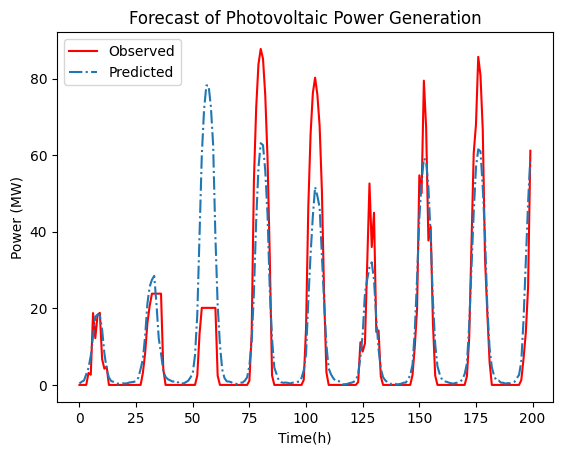

In [ ]:
fig = plt.figure()
# a1 = fig.add_axes([0,0,1,1])
# a1.set_ylim(-5,100)
# a1.set_xlim(-5,100)

# plt.plot(original[200:400,], color = 'red', label = 'Observed')
# plt.plot(pred[200:400,], '-.', label = 'Predicted')    

plt.plot(original[100:300,], color = 'red', label = 'Observed')
plt.plot(pred[100:300,], '-.', label = 'Predicted')  # ningbo 100-300 jinhua 200-400

# plt.ylim(-0.1,1.4)
# plt.ylim(-5,100)
plt.title('Forecast of Photovoltaic Power Generation')
plt.xlabel('Time(h)')
plt.ylabel('Power (MW)')
plt.legend(loc = 'upper left')
plt.savefig('/home/lenovo/wuyuhan3/original_data/PredictModel/Fig_truepre/GRU/ningbo_r08.jpg',dpi = 300)
plt.show()

ori = np.array(df[-3000:-585])[:,100]
x_ori = np.linspace(1,2415,2415)
x_pred = np.linspace(2415,3000,100)
plt.plot(x_ori,ori,label = 'Observed')
plt.plot(x_pred,pred,color = 'red',label = 'Predicted')
plt.title('Forecast with Updates')
plt.xlabel('Time')
plt.ylabel('Power consumption')
plt.legend()
plt.show()

In [ ]:
full_ori = np.array(df[-3000:])[:,54]
plt.plot(full_ori,color='blue')
plt.title('actual')
plt.xlabel('Time')
plt.ylabel('Power consumption')
plt.show()

原计算误差，预测值与真实值的差值

In [ ]:
def val(y_real,y_pred):
    MSE = metrics.mean_squared_error(y_real,y_pred)
    RMSE = metrics.mean_squared_error(y_real,y_pred)**0.5
    MAE = metrics.mean_absolute_error(y_real,y_pred)
    R2 = metrics.r2_score(y_real,y_pred)
    
    print("MSE:",MSE)
    print("RMSE:",RMSE)
    print("MAE:",MAE)
    print("R2:",R2)
val(original,pred)


In [ ]:
error = original[:]-pred[:]
R2 = metrics.r2_score(original,pred)
# R2 = R2_0(original,pred)
print(R2)

In [ ]:
plt.plot(error,'.')
plt.ylim([-20,20])
plt.title('Error')
plt.xlabel('Time')
plt.ylabel('Error')
# plt.savefig('figs/error_example.png',dpi = 300)
plt.show()

计算RMSE

In [ ]:
rootMeanSquaredError = np.power(np.sum(np.power(error,2))/len(error),0.5)
print(rootMeanSquaredError)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
#保存模型
grid_model.save('./ningbo_r08_800ep.h5')

导入模型进行预测，Time单位与数据的time时间分辨率一致，如1Time代表15min

In [ ]:
# import tensorflow as tf
# new_model = tf.keras.models.load_model('./ningbo_r08_800ep.h5')
# prediction=new_model(testX)
# prediction_copies_array = np.repeat(prediction,54, axis=-1)
# pred=scaler.inverse_transform(np.reshape(prediction_copies_array,(len(prediction),54)))
# print(pred.shape)
# pred = pred[:240,100]
# plt.plot(pred, '-.', label = 'Predicted')
# plt.title('Forecast with Updates')
# plt.xlabel('Time')
# plt.ylabel('Power consumption')
# plt.legend()
# # plt.savefig('./figs/ningbo_r08_800ep.png', dpi = 300)
# plt.show()